# Explore yfinance Data

Fetch OHLCV data for a ticker and compute metrics.

In [51]:
import yfinance as yf
import pandas as pd

# Define constants - use Apple ticker
TICKER = 'AAPL'
TRAIN_START = '2015-01-01'
TEST_END = '2024-12-31'

MARKET_TICKER = 'SPY'
GROWTH_WINDOWS = [1, 2, 3, 5, 10, 20]

In [52]:
%pip install yfinance pandas ta matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Download data

In [53]:
def download_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    df.index = df.index.tz_localize(None)
    return df

In [54]:
df = download_ticker(TICKER, start=TRAIN_START, end=TEST_END)
print(f'{len(df)} rows  ({df.index[0].date()} to {df.index[-1].date()})')
df.head()

2515 rows  (2015-01-02 to 2024-12-30)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02,24.648441,24.659506,23.754468,24.192604,212818400,0.0,0.0
2015-01-05,23.962469,24.042131,23.325182,23.511057,257142000,0.0,0.0
2015-01-06,23.575228,23.772167,23.152581,23.513269,263188400,0.0,0.0
2015-01-07,23.721278,23.942559,23.610638,23.842983,160423600,0.0,0.0
2015-01-08,24.170481,24.816620,24.053201,24.759087,237458000,0.0,0.0


In [55]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2515 non-null   float64
 1   High          2515 non-null   float64
 2   Low           2515 non-null   float64
 3   Close         2515 non-null   float64
 4   Volume        2515 non-null   int64  
 5   Dividends     2515 non-null   float64
 6   Stock Splits  2515 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 157.2 KB


In [56]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.000000,2515.000000
mean,93.535692,94.532237,92.611390,93.623189,1.171162e+08,0.003049,0.001590
std,65.177410,65.850856,64.573238,65.259577,6.839222e+07,0.024517,0.079761
min,20.488467,20.868641,20.367811,20.565865,2.323470e+07,0.000000,0.000000
25%,35.168896,35.540951,34.779565,35.138056,7.108655e+07,0.000000,0.000000
50%,64.013132,64.603150,63.447160,64.254379,1.003845e+08,0.000000,0.000000
75%,149.723847,151.665570,147.928989,149.941116,1.426222e+08,0.000000,0.000000
max,256.550862,258.448740,255.994420,257.375580,6.488252e+08,0.250000,4.000000


This shows that the Close values range from $20 to $257 which is quite large for training. Volume also has a large range from 23 million to 649 million.

## 2. Compute technical indicators

The `ta` library takes the OHLCV columns and computes each indicator. Each class returns an object with methods that give back a pandas Series, which I assign as a new column on the DataFrame.

In [57]:
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

features = df.copy()

### RSI

RSI is a momentum indicator that assesses the ratio of relative gain to relative loss. It determines the strength of price movements by comparing the number of positive and negative price changes (Mostafavi & Hooman, 2025). Values above 70 suggest the stock may be overbought; values below 30 suggest it may be oversold.

In [58]:
features['rsi'] = RSIIndicator(close=features['Close'], window=14).rsi()
features[['Close', 'rsi']].tail(10)

,Close,rsi
Date,,
2024-12-16,249.446259,78.747852
2024-12-17,251.870789,80.923062
2024-12-18,246.475266,64.983037
2024-12-19,248.204208,67.211810
2024-12-20,252.874359,72.334130
2024-12-23,253.649429,73.085629
2024-12-24,256.560822,75.750251
2024-12-26,257.375580,76.452842
2024-12-27,253.967361,67.626233


### MACD

MACD is derived by subtracting the 26-period EMA from the 12-period EMA. The signal line is a 9-period EMA of the MACD line itself (Mostafavi & Hooman, 2025). When the MACD line crosses above the signal line it suggests upward momentum is building; a cross below suggests the opposite.

In [59]:
macd = MACD(close=features['Close'])
features['macd']        = macd.macd()
features['macd_signal'] = macd.macd_signal()
features[['Close', 'macd', 'macd_signal']].tail(10)

,Close,macd,macd_signal
Date,,,
2024-12-16,249.446259,5.393174,4.408382
2024-12-17,251.870789,5.710390,4.668784
2024-12-18,246.475266,5.463434,4.827714
2024-12-19,248.204208,5.345610,4.931293
2024-12-20,252.874359,5.564926,5.058020
2024-12-23,253.649429,5.735166,5.193449
2024-12-24,256.560822,6.035435,5.361846
2024-12-26,257.375580,6.266904,5.542858
2024-12-27,253.967361,6.104955,5.655277


### Bollinger Bands

Bollinger Bands are volatility bands placed above and below a moving average, calculated using standard deviation. They adjust as volatility levels change. When the price reaches the upper band it may indicate an overbought signal; reaching the lower band may suggest an oversold signal (Mostafavi & Hooman, 2025).

In [60]:
bb = BollingerBands(close=features['Close'], window=20, window_dev=2)
features['bb_upper'] = bb.bollinger_hband()
features['bb_mid']   = bb.bollinger_mavg()
features['bb_lower'] = bb.bollinger_lband()
features[['Close', 'bb_upper', 'bb_mid', 'bb_lower']].tail(10)

,Close,bb_upper,bb_mid,bb_lower
Date,,,,
2024-12-16,249.446259,252.794382,237.639211,222.484039
2024-12-17,251.870789,254.373195,238.904128,223.435062
2024-12-18,246.475266,254.642510,239.886353,225.130197
2024-12-19,248.204208,254.949867,240.919254,226.888640
2024-12-20,252.874359,255.641539,242.209509,228.777479
2024-12-23,253.649429,256.204957,243.471447,230.737937
2024-12-24,256.560822,257.414123,244.729906,232.045690
2024-12-26,257.375580,258.659407,245.920300,233.181193
2024-12-27,253.967361,258.773097,246.946741,235.120386


### ATR

ATR measures price volatility. Larger true ranges indicate stronger back-and-forth price movements (Mostafavi & Hooman, 2025). It tells the model how much the stock typically moves in a day, which helps the RL agent scale its position sizing decisions.

In [61]:
features['atr'] = AverageTrueRange(
    high=features['High'], low=features['Low'], close=features['Close'], window=14
).average_true_range()
features[['Close', 'atr']].tail(10)

,Close,atr
Date,,
2024-12-16,249.446259,3.549474
2024-12-17,251.870789,3.583390
2024-12-18,246.475266,3.791610
2024-12-19,248.204208,3.869269
2024-12-20,252.874359,4.253671
2024-12-23,253.649429,4.105982
2024-12-24,256.560822,4.021363
2024-12-26,257.375580,3.909431
2024-12-27,253.967361,4.053197


### OBV

A running total of volume: it adds the day's volume when the price closes up and subtracts it when the price closes down. Rising OBV alongside rising price confirms the trend. Divergence between OBV and price can signal a coming reversal.

In [62]:
features['obv'] = OnBalanceVolumeIndicator(
    close=features['Close'], volume=features['Volume']
).on_balance_volume()
features[['Close', 'Volume', 'obv']].tail(10)

,Close,Volume,obv
Date,,,
2024-12-16,249.446259,51694800,7082443800
2024-12-17,251.870789,51356400,7133800200
2024-12-18,246.475266,56774100,7077026100
2024-12-19,248.204208,60882300,7137908400
2024-12-20,252.874359,147495300,7285403700
2024-12-23,253.649429,40858800,7326262500
2024-12-24,256.560822,23234700,7349497200
2024-12-26,257.375580,27237100,7376734300
2024-12-27,253.967361,42355300,7334379000


### HLC3

HLC3 calculates the average of the High, Low, and Close prices for a period. It is used as a smoothing technique to reduce price volatility (Mostafavi & Hooman, 2025). It gives a more stable price reference than Close alone because it accounts for the full range of the day's movement.

In [63]:
features['hlc3'] = (features['High'] + features['Low'] + features['Close']) / 3
features[['High', 'Low', 'Close', 'hlc3']].tail(10)

,High,Low,Close,hlc3
Date,,,,
2024-12-16,249.784112,246.077781,249.446259,248.436050
2024-12-17,252.218573,248.194281,251.870789,250.761214
2024-12-18,252.665710,246.167236,246.475266,248.436071
2024-12-19,250.400185,245.521352,248.204208,248.041915
2024-12-20,253.381116,244.130223,252.874359,250.128566
2024-12-23,254.027007,251.840976,253.649429,253.172471
2024-12-24,256.570737,253.669277,256.560822,255.600279
2024-12-26,258.448740,255.994420,257.375580,257.272913
2024-12-27,257.057633,251.453425,253.967361,254.159473


### Final feature set

In [64]:
features = features.dropna()
print(f'{len(features)} rows, {len(features.columns)} columns')
features.tail()

2482 rows, 16 columns


,Open,High,Low,Close,Volume,Dividends,Stock Splits,rsi,macd,macd_signal,bb_upper,bb_mid,bb_lower,atr,obv,hlc3
Date,,,,,,,,,,,,,,,,
2024-12-23,253.152604,254.027007,251.840976,253.649429,40858800,0.0,0.0,73.085629,5.735166,5.193449,256.204957,243.471447,230.737937,4.105982,7326262500,253.172471
2024-12-24,253.868019,256.570737,253.669277,256.560822,23234700,0.0,0.0,75.750251,6.035435,5.361846,257.414123,244.729906,232.045690,4.021363,7349497200,255.600279
2024-12-26,256.550862,258.448740,255.994420,257.375580,27237100,0.0,0.0,76.452842,6.266904,5.542858,258.659407,245.920300,233.181193,3.909431,7376734300,257.272913
2024-12-27,256.193131,257.057633,251.453425,253.967361,42355300,0.0,0.0,67.626233,6.104955,5.655277,258.773097,246.946741,235.120386,4.053197,7334379000,254.159473
2024-12-30,250.628701,251.890642,249.158101,250.598892,35557500,0.0,0.0,60.225564,5.639791,5.652180,258.437313,247.685520,236.933728,4.107202,7298821500,250.549212


## 3. Charts

In [65]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

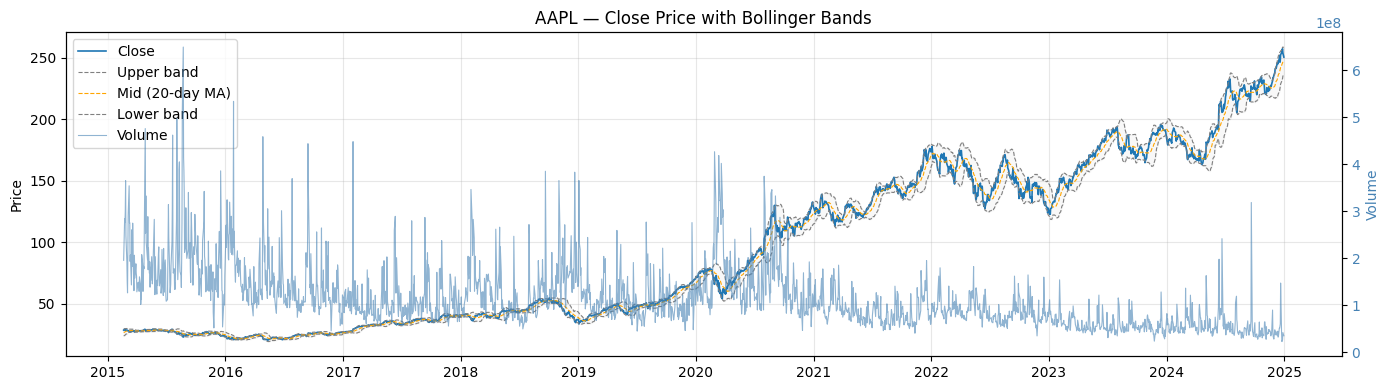

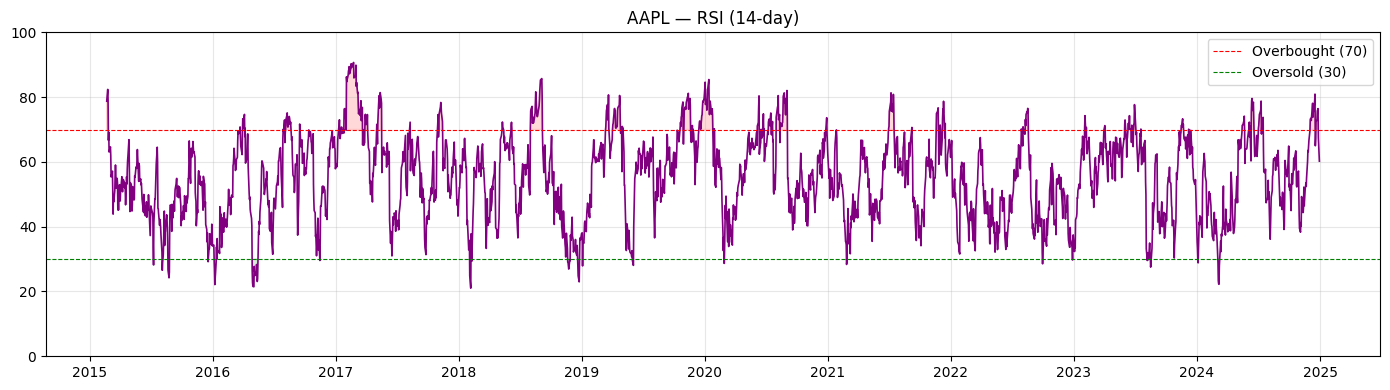

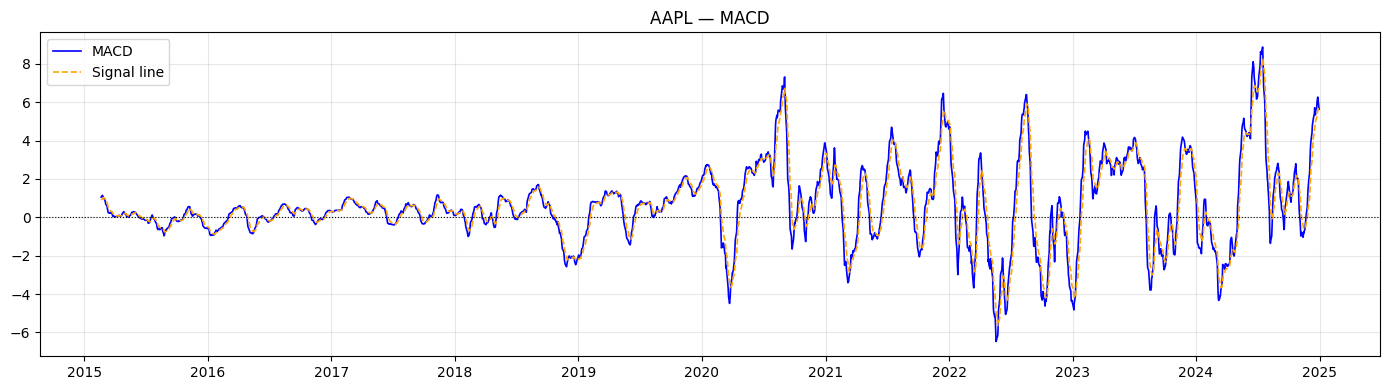

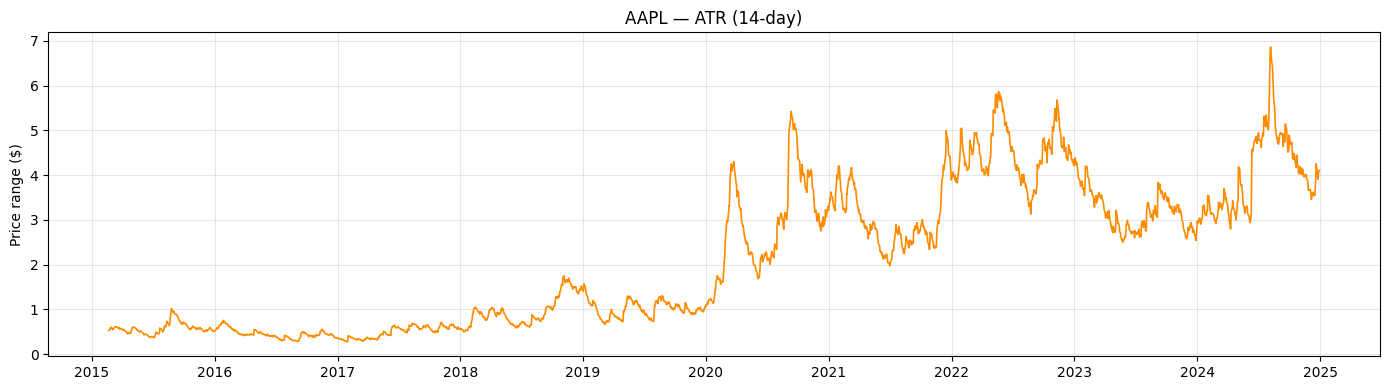

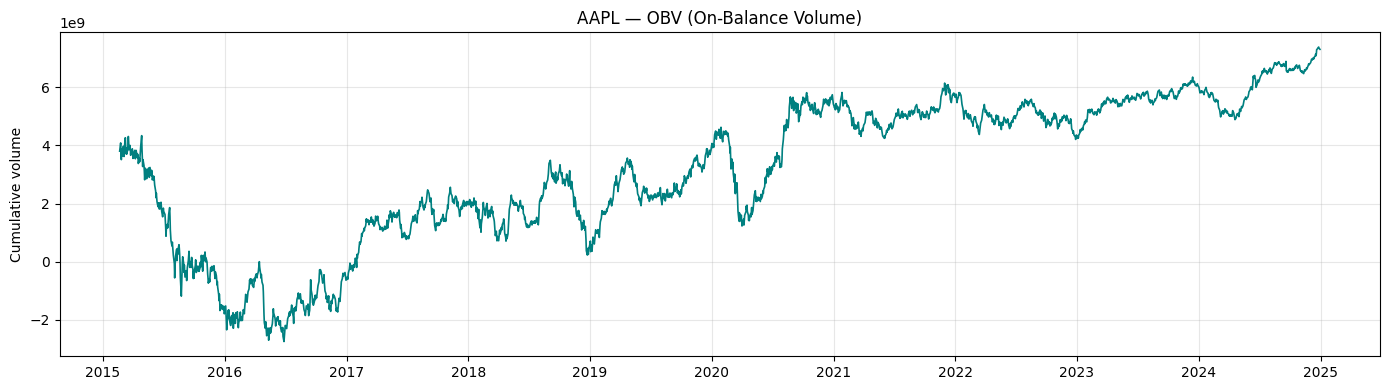

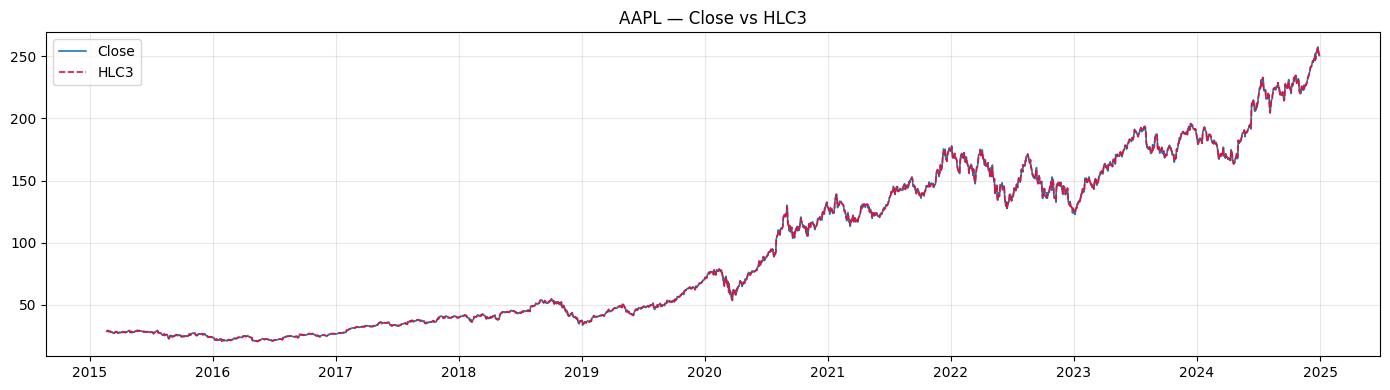

In [66]:
# Plot Close price with Bollinger Bands
fig, ax = plt.subplots()
ax_volume = ax.twinx()
ax_volume.plot(features.index, features['Volume'], label='Volume', linewidth=0.8, alpha=0.6, color='steelblue')
ax_volume.set_ylabel('Volume', color='steelblue')
ax_volume.tick_params(axis='y', labelcolor='steelblue')
ax_volume.grid(False)

ax.plot(features.index, features['Close'], label='Close', linewidth=1.2)
ax.plot(features.index, features['bb_upper'], label='Upper band', linestyle='--', linewidth=0.8, color='grey')
ax.plot(features.index, features['bb_mid'],   label='Mid (20-day MA)', linestyle='--', linewidth=0.8, color='orange')
ax.plot(features.index, features['bb_lower'], label='Lower band', linestyle='--', linewidth=0.8, color='grey')
ax.fill_between(features.index, features['bb_upper'], features['bb_lower'], alpha=0.05, color='grey')
ax.set_title(f'{TICKER} — Close Price with Bollinger Bands')
ax.set_ylabel('Price')

price_lines, price_labels = ax.get_legend_handles_labels()
volume_lines, volume_labels = ax_volume.get_legend_handles_labels()
ax.legend(price_lines + volume_lines, price_labels + volume_labels, loc='upper left')
plt.tight_layout()
plt.show()

# Plot RSI with overbought/oversold thresholds
fig, ax = plt.subplots()
ax.plot(features.index, features['rsi'], linewidth=1.2, color='purple')
ax.axhline(70, linestyle='--', linewidth=0.8, color='red',   label='Overbought (70)')
ax.axhline(30, linestyle='--', linewidth=0.8, color='green', label='Oversold (30)')
ax.fill_between(features.index, features['rsi'], 70, where=(features['rsi'] >= 70), alpha=0.15, color='red')
ax.fill_between(features.index, features['rsi'], 30, where=(features['rsi'] <= 30), alpha=0.15, color='green')
ax.set_title(f'{TICKER} — RSI (14-day)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

# Plot MACD and signal line
fig, ax = plt.subplots()
ax.plot(features.index, features['macd'],        label='MACD',         linewidth=1.2, color='blue')
ax.plot(features.index, features['macd_signal'], label='Signal line',  linewidth=1.2, color='orange', linestyle='--')
ax.axhline(0, linewidth=0.8, color='black', linestyle=':')
ax.set_title(f'{TICKER} — MACD')
ax.legend()
plt.tight_layout()
plt.show()

# Plot ATR
fig, ax = plt.subplots()
ax.plot(features.index, features['atr'], linewidth=1.2, color='darkorange')
ax.set_title(f'{TICKER} — ATR (14-day)')
ax.set_ylabel('Price range ($)')
plt.tight_layout()
plt.show()

# Plot OBV
fig, ax = plt.subplots()
ax.plot(features.index, features['obv'], linewidth=1.2, color='teal')
ax.set_title(f'{TICKER} — OBV (On-Balance Volume)')
ax.set_ylabel('Cumulative volume')
plt.tight_layout()
plt.show()

# Plot Close vs HLC3
fig, ax = plt.subplots()
ax.plot(features.index, features['Close'], label='Close',  linewidth=1.2)
ax.plot(features.index, features['hlc3'],  label='HLC3',   linewidth=1.2, linestyle='--', color='crimson')
ax.set_title(f'{TICKER} — Close vs HLC3')
ax.legend()
plt.tight_layout()
plt.show()

## Use "returns" instead of absolute values
Most stocks have drastically different prices in 2026 than they did in 2015 and we need to be able to compare them relatively.  We can use the difference in price from the previous day as a percentage to have an even comparison across the whole time period.

In [67]:
close = features['Close']
features['target_close'] = close

for col in ['Open', 'High', 'Low', 'Close', 'Volume', 'hlc3', 'obv']:
    features[f'{col}_return'] = features[col].pct_change()

features['volume_ratio'] = features['Volume'] / features['Volume'].rolling(20).mean()
features['obv_change_to_avg_volume'] = features['obv'].diff() / features['Volume'].rolling(20).mean()
features['macd_to_close'] = features['macd'] / close
features['macd_signal_to_close'] = features['macd_signal'] / close
features['atr_to_close'] = features['atr'] / close
features['bb_upper_to_close'] = features['bb_upper'] / close
features['bb_mid_to_close'] = features['bb_mid'] / close
features['bb_lower_to_close'] = features['bb_lower'] / close


## Compare original and return-based features

These charts show why the model uses return-based or price-normalised features. The original values carry the absolute price level, while the transformed values show relative movement or position, making different time periods easier to compare.

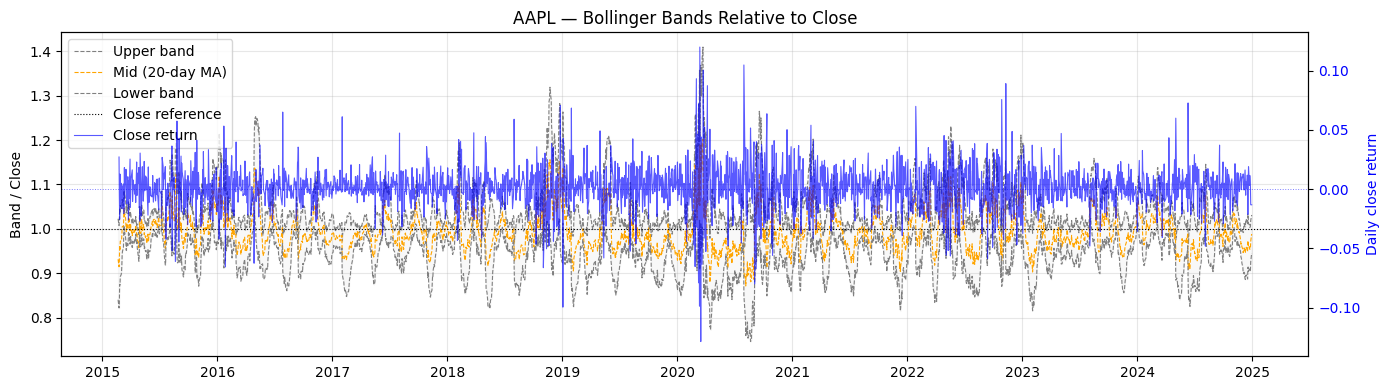

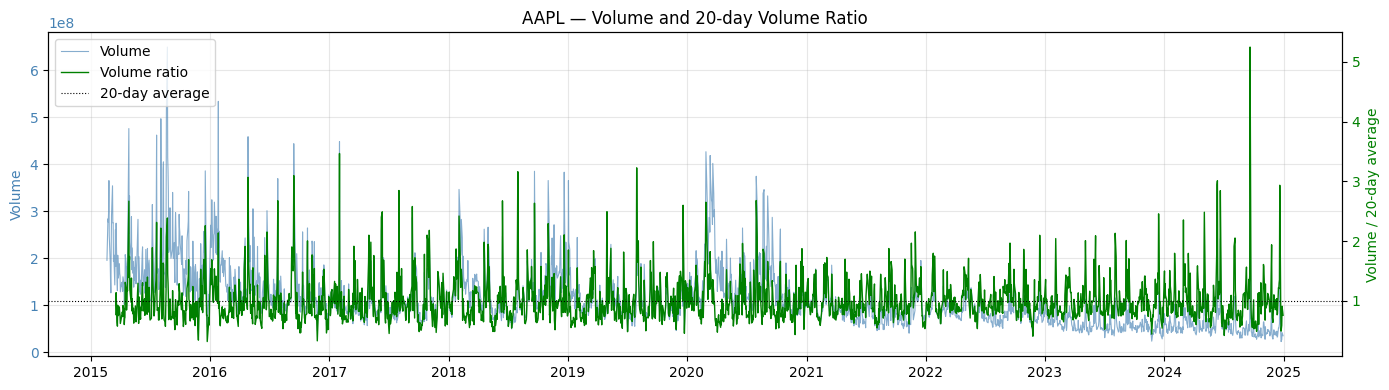

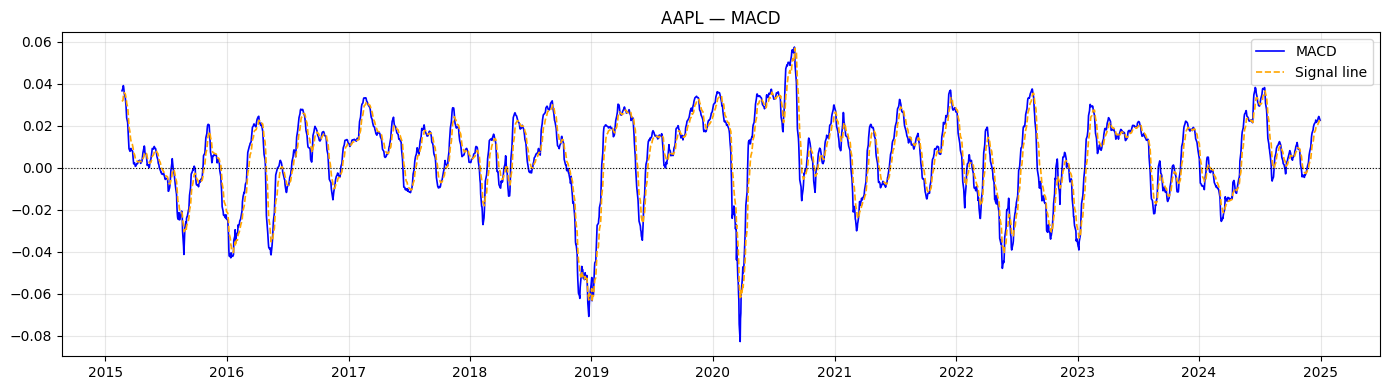

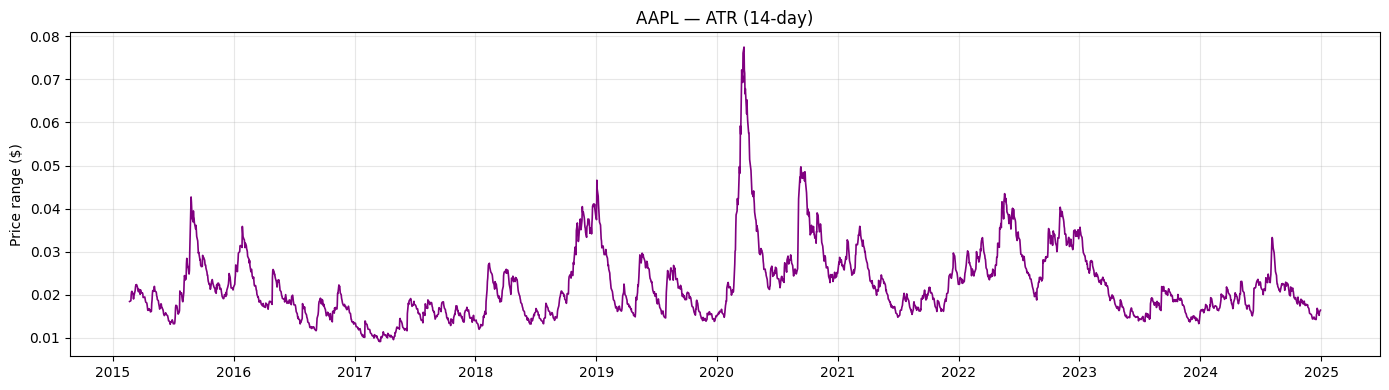

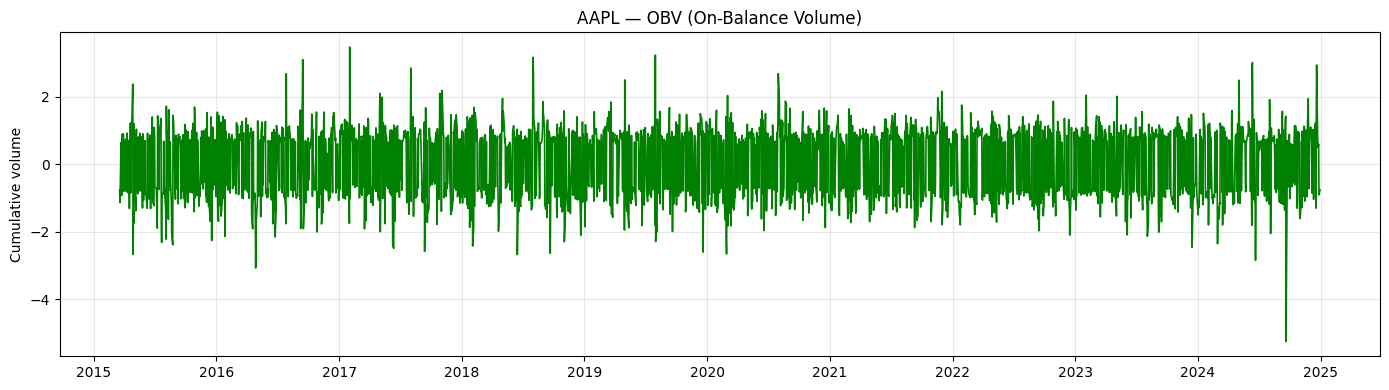

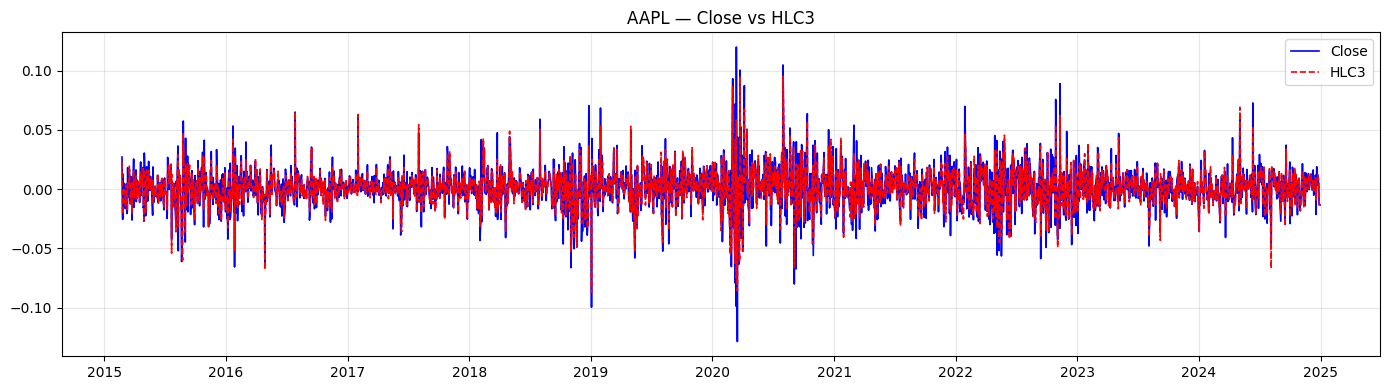

In [68]:
# Plot Close price with Bollinger Bands
fig, ax = plt.subplots()
ax.plot(features.index, features['bb_upper_to_close'], label='Upper band', linestyle='--', linewidth=0.8, color='grey')
ax.plot(features.index, features['bb_mid_to_close'],   label='Mid (20-day MA)', linestyle='--', linewidth=0.8, color='orange')
ax.plot(features.index, features['bb_lower_to_close'], label='Lower band', linestyle='--', linewidth=0.8, color='grey')
ax.fill_between(features.index, features['bb_upper_to_close'], features['bb_lower_to_close'], alpha=0.05, color='grey')
ax.axhline(1, color='black', linestyle=':', linewidth=0.8, label='Close reference')
ax.set_title(f'{TICKER} — Bollinger Bands Relative to Close')
ax.set_ylabel('Band / Close')

ax_close = ax.twinx()
ax_close.plot(features.index, features['Close_return'], label='Close return', linewidth=0.8, alpha=0.65, color='blue')
ax_close.axhline(0, color='blue', linestyle=':', linewidth=0.7, alpha=0.5)
ax_close.set_ylabel('Daily close return', color='blue')
ax_close.tick_params(axis='y', labelcolor='blue')
ax_close.grid(False)

price_lines, price_labels = ax.get_legend_handles_labels()
close_lines, close_labels = ax_close.get_legend_handles_labels()
ax.legend(price_lines + close_lines, price_labels + close_labels, loc='upper left')
plt.tight_layout()
plt.show()

# Plot volume and rolling volume ratio
fig, ax = plt.subplots()
ax_ratio = ax.twinx()

ax.plot(features.index, features['Volume'], label='Volume', linewidth=0.8, alpha=0.65, color='steelblue')
ax.set_title(f'{TICKER} — Volume and 20-day Volume Ratio')
ax.set_ylabel('Volume', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')

ax_ratio.plot(features.index, features['volume_ratio'], label='Volume ratio', linewidth=1.0, color='green')
ax_ratio.axhline(1, color='black', linestyle=':', linewidth=0.8, label='20-day average')
ax_ratio.set_ylabel('Volume / 20-day average', color='green')
ax_ratio.tick_params(axis='y', labelcolor='green')
ax_ratio.grid(False)

volume_lines, volume_labels = ax.get_legend_handles_labels()
ratio_lines, ratio_labels = ax_ratio.get_legend_handles_labels()
ax.legend(volume_lines + ratio_lines, volume_labels + ratio_labels, loc='upper left')
plt.tight_layout()
plt.show()

# Plot MACD and signal line
fig, ax = plt.subplots()
ax.plot(features.index, features['macd_to_close'],        label='MACD',         linewidth=1.2, color='blue')
ax.plot(features.index, features['macd_signal_to_close'], label='Signal line',  linewidth=1.2, color='orange', linestyle='--')
ax.axhline(0, linewidth=0.8, color='black', linestyle=':')
ax.set_title(f'{TICKER} — MACD')
ax.legend()
plt.tight_layout()
plt.show()

# Plot ATR
fig, ax = plt.subplots()
ax.plot(features.index, features['atr_to_close'], linewidth=1.2, color='purple')
ax.set_title(f'{TICKER} — ATR (14-day)')
ax.set_ylabel('Price range ($)')
plt.tight_layout()
plt.show()

# Plot OBV
fig, ax = plt.subplots()
ax.plot(features.index, features['obv_change_to_avg_volume'], linewidth=1.2, color='green')
ax.set_title(f'{TICKER} — OBV (On-Balance Volume)')
ax.set_ylabel('Cumulative volume')
plt.tight_layout()
plt.show()

# Plot Close vs HLC3
fig, ax = plt.subplots()
ax.plot(features.index, features['Close_return'], label='Close',  linewidth=1.2, color='blue')
ax.plot(features.index, features['hlc3_return'],  label='HLC3',   linewidth=1.2, linestyle='--', color='red')
ax.set_title(f'{TICKER} — Close vs HLC3')
ax.legend()
plt.tight_layout()
plt.show()

## Multi-window growth versus market

This section adds trailing growth features over several window sizes and compares each stock return to the market return over the same window. The market fields are the stock growth minus SPY growth, so positive values mean the stock outperformed the market over that lookback window.


In [69]:
market_df = download_ticker(MARKET_TICKER, start=TRAIN_START, end=TEST_END)
market_close = market_df['Close'].reindex(features.index).ffill()

features['market_close'] = market_close

# 1 day window growth calculations
features['growth_1d'] = features['target_close'].pct_change(1)
features['market_growth_1d'] = features['market_close'].pct_change(1)
features['excess_growth_vs_market_1d'] = features['growth_1d'] - features['market_growth_1d']
features['beat_market_1d'] = features['excess_growth_vs_market_1d'] > 0

# 2 day window growth calculations
features['growth_2d'] = features['target_close'].pct_change(2)
features['market_growth_2d'] = features['market_close'].pct_change(2)
features['excess_growth_vs_market_2d'] = features['growth_2d'] - features['market_growth_2d']
features['beat_market_2d'] = features['excess_growth_vs_market_2d'] > 0

# 3 day window growth calculations
features['growth_3d'] = features['target_close'].pct_change(3)
features['market_growth_3d'] = features['market_close'].pct_change(3)
features['excess_growth_vs_market_3d'] = features['growth_3d'] - features['market_growth_3d']
features['beat_market_3d'] = features['excess_growth_vs_market_3d'] > 0

# 5 day window growth calculations
features['growth_5d'] = features['target_close'].pct_change(5)
features['market_growth_5d'] = features['market_close'].pct_change(5)
features['excess_growth_vs_market_5d'] = features['growth_5d'] - features['market_growth_5d']
features['beat_market_5d'] = features['excess_growth_vs_market_5d'] > 0

# 10 day window growth calculations
features['growth_10d'] = features['target_close'].pct_change(10)
features['market_growth_10d'] = features['market_close'].pct_change(10)
features['excess_growth_vs_market_10d'] = features['growth_10d'] - features['market_growth_10d']
features['beat_market_10d'] = features['excess_growth_vs_market_10d'] > 0

# 20 day window growth calculations
features['growth_20d'] = features['target_close'].pct_change(20)
features['market_growth_20d'] = features['market_close'].pct_change(20)
features['excess_growth_vs_market_20d'] = features['growth_20d'] - features['market_growth_20d']
features['beat_market_20d'] = features['excess_growth_vs_market_20d'] > 0

## Chart the growth features

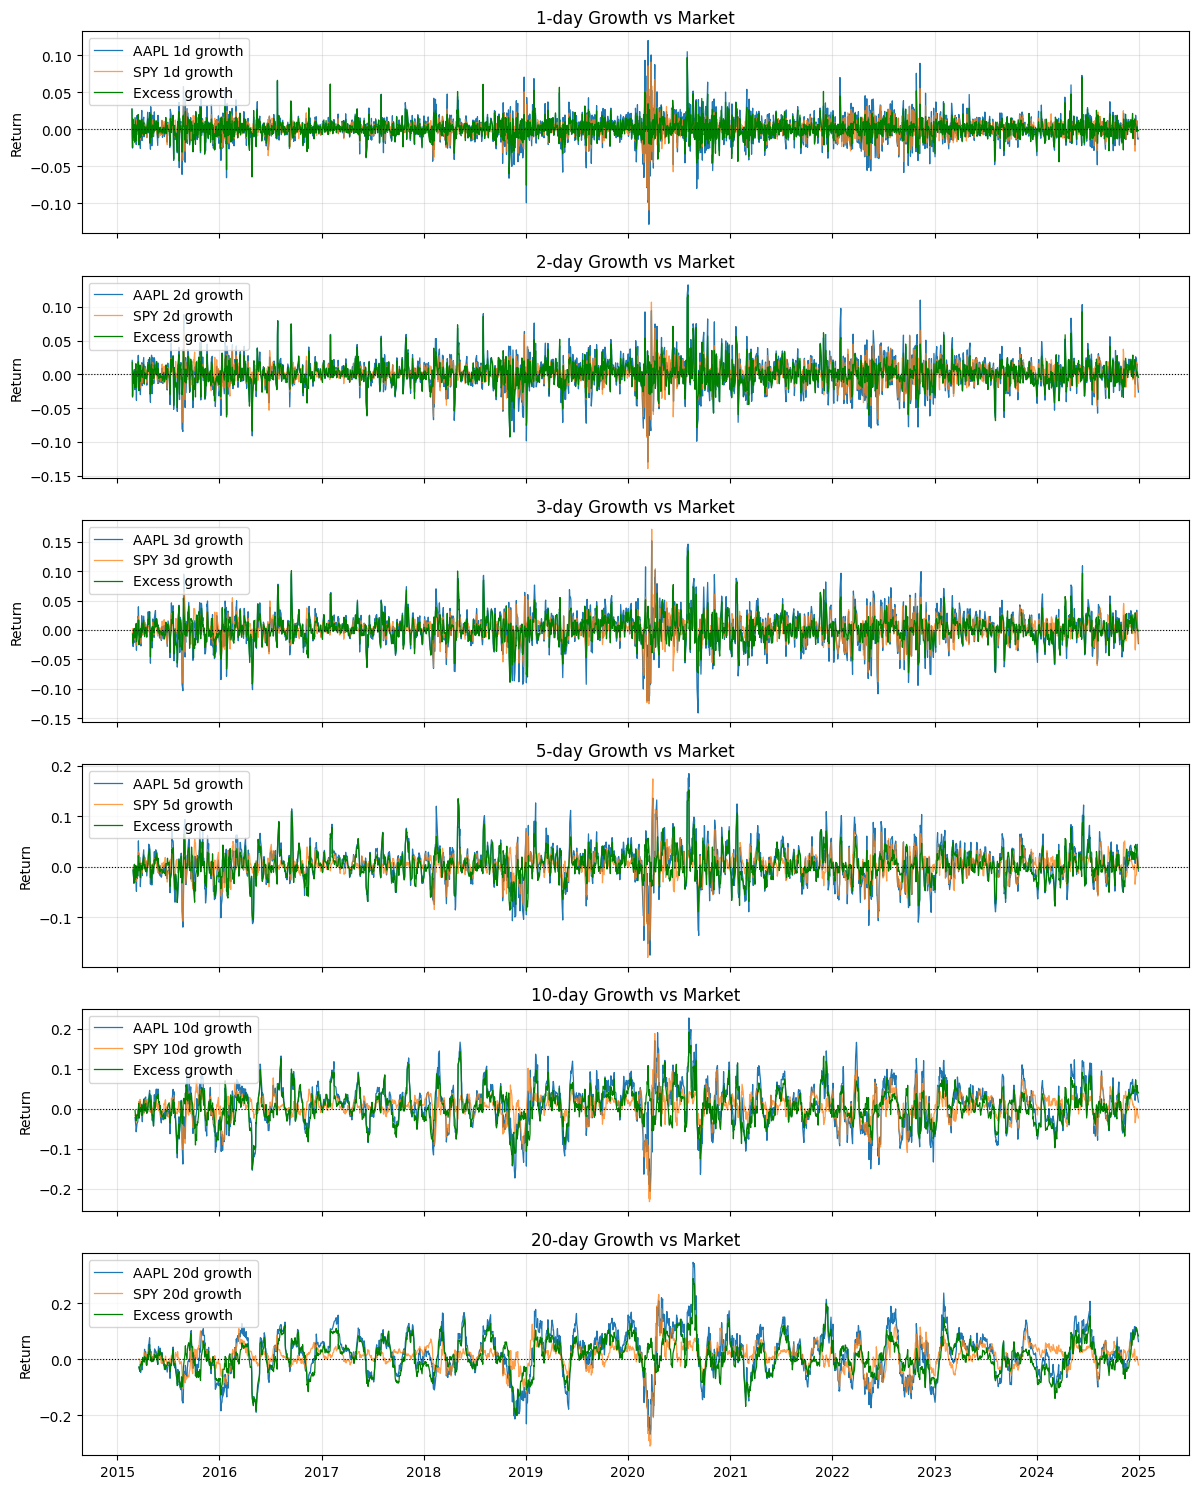

In [71]:
fig, axes = plt.subplots(len(GROWTH_WINDOWS), 1, figsize=(12, 2.5 * len(GROWTH_WINDOWS)), sharex=True)

for ax, window in zip(axes, GROWTH_WINDOWS):
    stock_col = f'growth_{window}d'
    market_col = f'market_growth_{window}d'
    excess_col = f'excess_growth_vs_market_{window}d'

    ax.plot(features.index, features[stock_col], label=f'{TICKER} {window}d growth', linewidth=0.9)
    ax.plot(features.index, features[market_col], label=f'{MARKET_TICKER} {window}d growth', linewidth=0.9, alpha=0.75)
    ax.plot(features.index, features[excess_col], label='Excess growth', linewidth=0.9, color='green')

    ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
    ax.set_title(f'{window}-day Growth vs Market')
    ax.set_ylabel('Return')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



## References

Mostafavi, S. M., & Hooman, A. R. (2025). Key technical indicators for stock market prediction. *Machine Learning with Applications*, 20, 100631. https://doi.org/10.1016/j.mlwa.2025.100631